In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ruta = r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\01_raw\cibercriminalidad\05001.csv"

df = pd.read_csv(ruta, encoding='utf-8-sig', sep=None, engine='python')

# Quitar agregados
df = df[
    ~df['Comunidades autónomas'].isin(['TOTAL NACIONAL', 'DESCONOCIDA', 'EN EL EXTRANJERO'])
].copy()

# Quedarnos con el total de grupos penales y años 2014-2024
df_total = df[
    (df['Grupo penal'] == 'TOTAL grupo penal') &
    (df['periodo'] >= 2014)
].copy()

print(df_total.shape)
print(df_total['periodo'].unique())

(209, 4)
[2024 2023 2022 2021 2020 2019 2018 2017 2016 2015 2014]


In [8]:
# Limpiar nombres de comunidad (mismo patrón que datasets anteriores)
df_total['Comunidades autónomas'] = (
    df_total['Comunidades autónomas']
    .str.replace('ASTURIAS (PRINCIPADO DE)', 'Asturias', regex=False)
    .str.replace('BALEARS (ILLES)', 'Baleares', regex=False)
    .str.replace('CASTILLA - LA MANCHA', 'Castilla-La Mancha', regex=False)
    .str.replace('COMUNITAT VALENCIANA', 'Comunidad Valenciana', regex=False)
    .str.replace('MADRID (COMUNIDAD DE)', 'Madrid', regex=False)
    .str.replace('MURCIA (REGIÓN DE)', 'Murcia', regex=False)
    .str.replace('NAVARRA (COMUNIDAD FORAL DE)', 'Navarra', regex=False)
    .str.replace('RIOJA (LA)', 'La Rioja', regex=False)
    .str.replace('CIUDAD AUTÓNOMA DE CEUTA', 'Ceuta', regex=False)
    .str.replace('CIUDAD AUTÓNOMA DE MELILLA', 'Melilla', regex=False)
    .str.replace('CASTILLA Y LEÓN', 'Castilla y León', regex=False)
    .str.title()
)

df_total = df_total.rename(columns={
    'Comunidades autónomas': 'comunidad',
    'periodo': 'año',
    'Total': 'ciberdelitos'
})

# Limpiar Total: coma decimal → float
df_total['ciberdelitos'] = (
    df_total['ciberdelitos'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

print(df_total.shape)
print(sorted(df_total['comunidad'].unique()))

(209, 4)
['Andalucía', 'Aragón', 'Asturias', 'Baleares', 'Canarias', 'Cantabria', 'Castilla Y León', 'Castilla-La Mancha', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'La Rioja', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'País Vasco']


In [9]:
df_total['comunidad'] = df_total['comunidad'].str.replace('Castilla Y León', 'Castilla y León', regex=False)

print(sorted(df_total['comunidad'].unique()))

['Andalucía', 'Aragón', 'Asturias', 'Baleares', 'Canarias', 'Cantabria', 'Castilla y León', 'Castilla-La Mancha', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'La Rioja', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'País Vasco']


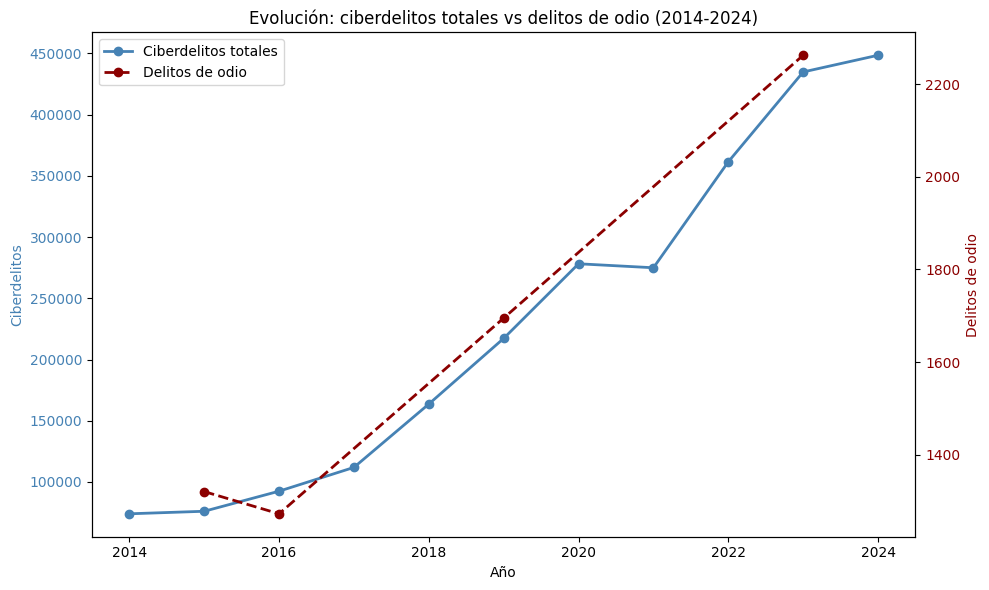

In [ ]:
# Evolución temporal nacional — ciberdelitos vs delitos de odio
evolucion_ciber = df_total.groupby('año')['ciberdelitos'].sum().reset_index()

# Cargar datos_final para comparar
datos = pd.read_csv(
    r"C:\Users\herre\OneDrive\Desktop\Proyectos DATA\SPRINT 13\01_data\03_final\datos_final.csv"
)

datos_anual = (
    datos
    .sort_values(["año", "mes"])
    .drop_duplicates(
        subset=["comunidad", "año"],
        keep="last"
    )
    .copy()
)

evolucion_odio = (
    datos_anual
    .groupby("año")["TOTAL ámbitos"]
    .sum()
    .reset_index()
)

# Comparar en un gráfico de doble eje
fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.plot(evolucion_ciber['año'], evolucion_ciber['ciberdelitos'],
         marker='o', color='steelblue', linewidth=2, label='Ciberdelitos totales')
ax1.set_xlabel('Año')
ax1.set_ylabel('Ciberdelitos', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.plot(evolucion_odio['año'], evolucion_odio['TOTAL ámbitos'],
         marker='o', color='darkred', linewidth=2, linestyle='--', label='Delitos de odio')
ax2.set_ylabel('Delitos de odio', color='darkred')
ax2.tick_params(axis='y', labelcolor='darkred')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title(
    "Evolución de ciberdelitos y delitos de odio "
    "(años electorales disponibles)"
)
plt.tight_layout()
plt.show()

## 2. Evolución comparada: ciberdelitos vs delitos de odio

Ambas variables crecen en el periodo 2014-2024, pero con patrones distintos:

- Los **ciberdelitos** muestran un crecimiento continuo y sostenido desde
  2016, multiplicándose por 6 en la década.
- Los **delitos de odio** crecen de forma más irregular, con una caída
  en 2016 y un salto brusco entre 2020 y 2023.

Los ciberdelitos empiezan a crecer antes que los delitos de odio, lo que
podría indicar que el entorno digital anticipó el aumento del fenómeno
en el registro oficial — aunque esta interpretación requiere cautela,
ya que ambas series miden fenómenos distintos con metodologías diferentes.

In [ ]:
# Evolución por grupo penal online (excluyendo TOTAL)
df_grupos = df[
    (df['Grupo penal'] != 'TOTAL grupo penal') &
    (df['periodo'] >= 2014)
].copy()

# Limpiar nombres comunidad y renombrar columnas
df_grupos['Comunidades autónomas'] = (
    df_grupos['Comunidades autónomas']
    .str.replace('ASTURIAS (PRINCIPADO DE)', 'Asturias', regex=False)
    .str.replace('BALEARS (ILLES)', 'Baleares', regex=False)
    .str.replace('CASTILLA - LA MANCHA', 'Castilla-La Mancha', regex=False)
    .str.replace('COMUNITAT VALENCIANA', 'Comunidad Valenciana', regex=False)
    .str.replace('MADRID (COMUNIDAD DE)', 'Madrid', regex=False)
    .str.replace('MURCIA (REGIÓN DE)', 'Murcia', regex=False)
    .str.replace('NAVARRA (COMUNIDAD FORAL DE)', 'Navarra', regex=False)
    .str.replace('RIOJA (LA)', 'La Rioja', regex=False)
    .str.replace('CIUDAD AUTÓNOMA DE CEUTA', 'Ceuta', regex=False)
    .str.replace('CIUDAD AUTÓNOMA DE MELILLA', 'Melilla', regex=False)
    .str.title()
    .str.replace('Castilla Y León', 'Castilla y León', regex=False)
)

df_grupos = df_grupos.rename(columns={
    'Comunidades autónomas': 'comunidad',
    'periodo': 'año',
    'Total': 'ciberdelitos'
})

df_grupos['ciberdelitos'] = (
    df_grupos['ciberdelitos'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

evolucion_grupos = df_grupos.groupby(['año', 'Grupo penal'])['ciberdelitos'].sum().reset_index()



<Figure size 1200x600 with 0 Axes>

In [13]:
print(df['Comunidades autónomas'].unique())
print(df.columns.tolist())

['ANDALUCÍA' 'ARAGÓN' 'ASTURIAS (PRINCIPADO DE)' 'BALEARS (ILLES)'
 'CANARIAS' 'CANTABRIA' 'CASTILLA Y LEÓN' 'CASTILLA - LA MANCHA'
 'CATALUÑA' 'COMUNITAT VALENCIANA' 'EXTREMADURA' 'GALICIA'
 'MADRID (COMUNIDAD DE)' 'MURCIA (REGIÓN DE)'
 'NAVARRA (COMUNIDAD FORAL DE)' 'PAÍS VASCO' 'RIOJA (LA)'
 'CIUDAD AUTÓNOMA DE CEUTA' 'CIUDAD AUTÓNOMA DE MELILLA']
['Comunidades autónomas', 'Grupo penal', 'periodo', 'Total']


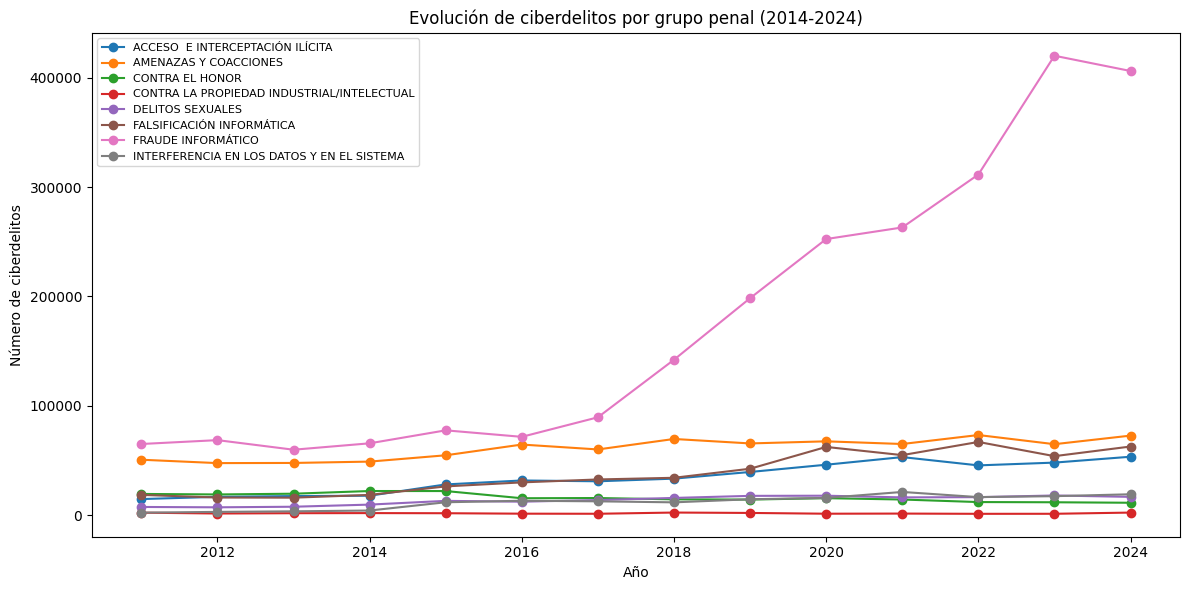

In [14]:
# Evolución por grupo penal online (excluyendo TOTAL)
df_grupos = df[
    df['Grupo penal'] != 'TOTAL grupo penal'
].copy()

# Limpiar Total
df_grupos['Total'] = (
    df_grupos['Total'].astype(str)
    .str.replace('.', '', regex=False)
    .str.replace(',', '.', regex=False)
    .pipe(pd.to_numeric, errors='coerce')
)

evolucion_grupos = df_grupos.groupby(
    ['periodo', 'Grupo penal']
)['Total'].sum().reset_index()

plt.figure(figsize=(12, 6))
for grupo in evolucion_grupos['Grupo penal'].unique():
    datos_grupo = evolucion_grupos[evolucion_grupos['Grupo penal'] == grupo]
    plt.plot(
        datos_grupo['periodo'],
        datos_grupo['Total'],
        marker='o',
        label=grupo
    )

plt.title('Evolución de ciberdelitos por grupo penal (2014-2024)')
plt.xlabel('Año')
plt.ylabel('Número de ciberdelitos')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Evolución por grupo penal online

El crecimiento de ciberdelitos está dominado casi exclusivamente por el
**fraude informático**, que pasa de ~70.000 casos en 2011 a más de
400.000 en 2023. El resto de categorías permanecen prácticamente estables.

Para la pregunta de investigación del proyecto, esto es relevante:

- **AMENAZAS Y COACCIONES** y **CONTRA EL HONOR** — los grupos penales
  online más cercanos al odio — no muestran crecimiento significativo.
- El crecimiento de ciberdelitos **no refleja un aumento del odio online**,
  sino principalmente un aumento del fraude económico digital.

Esto contrasta con el patrón presencial, donde los delitos de odio por
racismo/xenofobia y LGTBIfobia sí crecen fuertemente entre 2019 y 2023.

**Conclusión**: los datos oficiales de cibercriminalidad no confirman
que el aumento de delitos de odio presenciales tenga un correlato en
el entorno digital registrado por las fuerzas de seguridad. Si existe
odio online en crecimiento, no está siendo capturado por estas
estadísticas — lo que refuerza la necesidad de analizar el discurso
en redes sociales (fase NLP del proyecto) como fuente complementaria.